In this notebook, we create the baseline regression model relying on the spike counts of motor units as features.

The notebook with the current choice of parameters generates the following files:
- Intermediate files in *regression_data/S2/mu_regression* folder:
    - force_df_Trap_0_15_1_3_20_intra_hold_False.pkl
    - mu_df_sorted_Trap_0_15_1_3_20_intra_hold_False.pkl
    - mu_df_Trap_0_15_1_3_20_intra_hold_False.pkl
    - mu_summary_df_Trap_0_15_1_3_20_intra_hold_False.pkl

- Results files in *results/S2/fp32* folder:
    - metrics_df_intra_ws0.08_ol50_-1_15_cv_on_mu_nfing_1_2_3_4_5_shuffleseed_10_linear_hold_False.pkl
    - trained_models_intra_ws0.08_ol50_-1_15_cv_on_mu_nfing_1_2_3_4_5_shuffleseed_10_linear_hold_False.pkl
    - y_df_intra_ws0.08_ol50_-1_15_cv_on_mu_nfing_1_2_3_4_5_shuffleseed_10_linear_hold_False.pkl
    - y_dict_intra_ws0.08_ol50_-1_15_cv_on_mu_nfing_1_2_3_4_5_shuffleseed_10_linear_hold_False.pkl

In [10]:
import logging
import os
import json
import sys
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from matplotlib import gridspec
from matplotlib.patches import Patch
notebook_dir = os.getcwd()
project_dir = os.path.dirname(os.path.dirname(notebook_dir))

if project_dir not in sys.path:
    sys.path.insert(0, project_dir)
print(f'Notebook dir: {notebook_dir}\nProject dir: {project_dir}')

from force_regression.config.dataconfig import DataConfig
import force_regression.utils.functions as fn
from force_regression.models.linear_regression import ConventionalRegressionOnMu
from configs.constants import *
logging.getLogger().setLevel(logging.INFO)
%load_ext autoreload
%autoreload 2

Notebook dir: /Users/farahbaracat/Documents/PhD Research/Code/snn-fingerforce-decoding/notebooks/baselines
Project dir: /Users/farahbaracat/Documents/PhD Research/Code/snn-fingerforce-decoding
The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [11]:
config_path = os.path.join(project_dir, 'configs/config.json')

try:
    with open(config_path, 'r') as config_file:
        config = json.load(config_file)
        root_dir = os.path.join(project_dir, config['root_dir'])
        root_results_dir = os.path.join(project_dir, config['root_results_dir'])
        config['root_dir'] = root_dir
        config['root_results_dir'] = root_results_dir
        subject_mappings = config['subject_mappings']
        print(f'Root directory from config: {root_dir}')
except FileNotFoundError:
    print(f"Error: 'config.json' not found in {config_path}")
except json.JSONDecodeError:
    print("Error: 'config.json' is not a valid JSON file.")
except KeyError:
    print("Error: 'root_dir' not found in 'config.json'.")
except Exception as e:
    print(f"An unexpected error occurred: {e}")

Root directory from config: /Volumes/big usb drive/HDiEMG_mu_decomposition


# Set notebook parameters

This is parameter cell used to run the notebook with different parameters using Papermill


In [12]:
# UPDATE THESE PARAMETERS BEFORE RUNNING THE NOTEBOOK
subj = "S1"  # subject ID: S1 | S2
sign_mvc = 1   # movement direction: -1 (extension) | 1 (flexion)
# if True load pre-generated regression dataframes from file, else generate it
load_regression_data_from_file = False

profile = False  # if True, profile the model during prediction time
# KEEP THESE PARAMETERS UNCHANGED
mvc = 15     # MVC value used during the experiment
emg_type = 'intra' # emg_type is intramuscular EMG
model_type = 'linear' # linear regression model
overlap_in_perc = 50    # percentage overlap between the analysis windows
win_size_in_sec = 0.08  # window size in seconds
select_dir = True # parameter to select direction of force to be used for regression. If False, both directions are used.
load_multi = [mvc] # [mvc] the default is set to the given MVC value. Another option is a list of MVCs
sweep_win_size = False # flag to sweep on the window size. If True place results in a subfolder
segment_hold = False # if True, segment the hold phase of the force profile, else consider the full force profile
post_process = True  # if True, smooth the predicted force using a low-pass filter
shuffle_fingers_seed = 10  # seed used to shuffle the finger orders prior to cross-validation

# Create data configuration instance

In [13]:
config = DataConfig(root_dir=root_dir,
                    root_results_dir=root_results_dir,
                    subject=fn.reverse_remap(subj, subject_mappings),
                    task_type="Trap", 
                    finger_type="Individual", 
                    day="Day 1",
                    mvc=mvc, 
                    emg_type=emg_type, 
                    f_samp=10240,
                    subj_map=subject_mappings,
                    segment_hold=segment_hold,
                    verbose=True,
                    common_only=True,
                    images=False,
                    time_to_cut=1,
                    load_multi=load_multi,
                    convreg_temp_data_dir='regression_data',
                    figs_dir='figures')
config.sign_mvc = sign_mvc

In [14]:
config.load_multi, config.mvc, config.direction, config.emg_type, config.sign_mvc, config.segment_hold


([15], 15, 'flex', 'intra', 1, False)

In [15]:
sign_mvc, emg_type , config.emg_type, config.sign_mvc, mvc

(1, 'intra', 'intra', 1, 15)

In [16]:
config.decomp_dir

'/Volumes/big usb drive/HDiEMG_mu_decomposition/AK/Day 1/decomposition/Trap/15'

# Linear Regression with Motor Units

In [17]:
mu_reg = ConventionalRegressionOnMu(model_type,
                                    config,
                                    emg_type,
                                    regression_data_parent_dir=config.convreg_temp_data_path,
                                    overlap_in_perc=overlap_in_perc,
                                    window_size_in_sec=win_size_in_sec,
                                    post_process=post_process,
                                    load_regression_data_from_file=load_regression_data_from_file,
                                    shuffle_fingers_seed=shuffle_fingers_seed
                                    )

INFO:root:Loading sensor: 6 in flex (606125 samples)
INFO:root:Segmenting data for rep1 from 0.81240234375 to 28.75 and rep2 from 30.8126953125 to 58.75029296875


File Trap_0_15_1_1_3_20.mat loaded successfully with mat73
thumb | flex | start rep1 0.81240234375
---------------------------------------------
Found 1 units with abnormal firing rates.
Unit 12 fr rep 1: 0.00 Hz, fr rep 2: 2.86 Hz. Removing...
---------------------------------------------
---------------------------------------------
Found 0 units with abnormal firing rates.
---------------------------------------------
Found 6 units with abnormal firing rates.
Unit 7 fr rep 1: 2.36 Hz, fr rep 2: 0.21 Hz. Removing...
Unit 13 fr rep 1: 0.00 Hz, fr rep 2: 1.11 Hz. Removing...
Unit 14 fr rep 1: 0.00 Hz, fr rep 2: 2.00 Hz. Removing...
Unit 15 fr rep 1: 0.00 Hz, fr rep 2: 0.68 Hz. Removing...
Unit 16 fr rep 1: 0.00 Hz, fr rep 2: 2.07 Hz. Removing...
Unit 17 fr rep 1: 0.00 Hz, fr rep 2: 0.96 Hz. Removing...
---------------------------------------------


/Users/farahbaracat/Documents/PhD Research/Code/snn-fingerforce-decoding/force_regression/data/handlers/mu_handler.py:183: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  mu_df = pd.concat([mu_df, electrode_mu_df], ignore_index=True)
INFO:root:Loading sensor: 1 in ext (597745 samples)
INFO:root:Segmenting data for rep1 from 1.06240234375 to 29.0 and rep2 from 30.49990234375 to 58.4375


File Trap_0_-15_1_1_3_20.mat loaded successfully with mat73
thumb | ext | start rep1 1.06240234375
---------------------------------------------
Found 0 units with abnormal firing rates.
---------------------------------------------
Found 7 units with abnormal firing rates.
Unit 2 fr rep 1: 2.50 Hz, fr rep 2: 0.29 Hz. Removing...
Unit 10 fr rep 1: 1.61 Hz, fr rep 2: 0.68 Hz. Removing...
Unit 14 fr rep 1: 0.25 Hz, fr rep 2: 2.89 Hz. Removing...
Unit 17 fr rep 1: 0.04 Hz, fr rep 2: 2.46 Hz. Removing...
Unit 19 fr rep 1: 0.00 Hz, fr rep 2: 2.32 Hz. Removing...
Unit 21 fr rep 1: 0.00 Hz, fr rep 2: 3.96 Hz. Removing...
Unit 22 fr rep 1: 0.00 Hz, fr rep 2: 1.86 Hz. Removing...
---------------------------------------------
---------------------------------------------
Found 0 units with abnormal firing rates.


INFO:root:Loading sensor: 7 in flex (600994 samples)
INFO:root:Segmenting data for rep1 from 0.93740234375 to 28.875 and rep2 from 30.31171875 to 58.24931640625


...

little  force_avg:(697, 5) 


INFO:root:middle duration: 27.93759765625


middle  force_avg:(697, 5) 


INFO:root:thumb duration: 27.93759765625
INFO:root:Rep 2 (3485, 244) all repetitions: (6970, 244)


thumb  force_avg:(697, 5) 


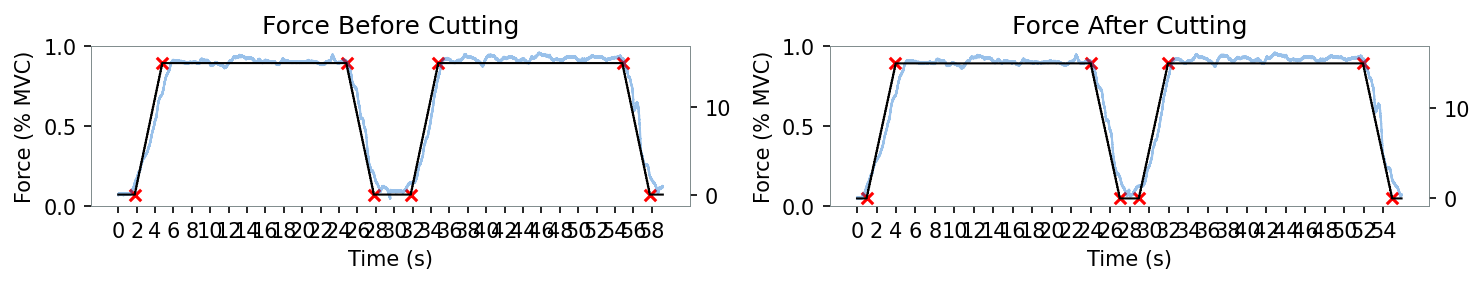

In [18]:
mu_reg.create_mu_regression_df()

In [22]:
# Print number of windows after binning spike counts for each repetition and finger
mu_reg.windows_count_for_finger, mu_reg.data_config.direction


({0: {5: 697, 1: 697, 2: 697, 3: 697, 4: 697},
  1: {2: 697, 4: 697, 5: 697, 3: 697, 1: 697}},
 'flex')

In [23]:
metrics_df_cv, y_df_cv, trained_models_df = mu_reg.cross_validate_model()


Fitting on input_train rep 2: (3485, 121)  y_train:(3485, 5)
Mean metrics across fingers df
+-----------------+----------+
|                 |        0 |
|-----------------+----------|
| RMSE_test       | 1.52198  |
| RMSE_train      | 1.30123  |
| RMSE_train_post | 0.923033 |
| RMSE_test_post  | 1.21906  |
| MAE_test        | 0.851651 |
| MAE_train       | 0.622292 |
| MAE_train_post  | 0.431184 |
| MAE_test_post   | 0.717341 |
| R2_test         | 0.91567  |
| R2_train        | 0.93803  |
| R2_train_post   | 0.968375 |
| R2_test_post    | 0.945459 |
+-----------------+----------+

Fitting on input_train rep 1: (3485, 121)  y_train:(3485, 5)
Mean metrics across fingers df
+-----------------+----------+
|                 |        0 |
|-----------------+----------|
| RMSE_test       | 1.68312  |
| RMSE_train      | 1.06998  |
| RMSE_train_post | 0.668774 |
| RMSE_test_post  | 1.39791  |
| MAE_test        | 0.938885 |
| MAE_train       | 0.487456 |
| MAE_train_post  | 0.325162 |
| MAE_te

In [20]:
if profile:
    # Testing the profile_model function
    profiling_results = mu_reg.profile_model(trained_models_df,
                         mu_reg.reg_data_df,
                         non_mus_cols=mu_reg.data_config.force_cols_list + mu_reg.force_aux_cols,
                         verbose=True)
    mu_reg.save_profiling_results(profiling_results)

In [48]:
metrics_df_cv

,RMSE_test,RMSE_train,RMSE_train_post,RMSE_test_post,MAE_test,MAE_train,MAE_train_post,MAE_test_post,R2_test,R2_train,R2_train_post,R2_test_post,test_on_rep,fold,input_dur,fing_id
0,1.617074,1.493492,1.005563,1.171773,0.823342,0.605721,0.392561,0.652338,0.910340,0.927636,0.967195,0.952921,1,0,0.08,5
1,1.741470,1.454987,1.037810,1.442161,0.835292,0.614276,0.431403,0.744031,0.890416,0.925565,0.962130,0.924848,1,0,0.08,1
2,1.514797,1.231653,0.900849,1.270002,1.045342,0.735193,0.530609,0.898968,0.912355,0.943041,0.969529,0.938393,1,0,0.08,2
3,1.478918,1.027884,0.648156,1.256514,0.935266,0.561192,0.362669,0.815554,0.923067,0.960230,0.984186,0.944466,1,0,0.08,3
4,1.257658,1.298157,1.022786,0.954858,0.619014,0.595080,0.438679,0.475812,0.942173,0.933680,0.958832,0.966666,1,0,0.08,4
0,1.622412,1.443015,0.805609,1.067358,0.815848,0.517617,0.323462,0.614860,0.914604,0.928603,0.977747,0.963040,2,1,0.08,2
1,1.742044,1.055818,0.651089,1.481530,0.869958,0.450575,0.309028,0.770594,0.893297,0.959720,0.984682,0.922824,2,1,0.08,4
2,1.883207,0.872034,0.577133,1.728646,1.262562,0.488262,0.336005,1.161347,0.866838,0.970954,0.987277,0.887799,2,1,0.08,5
3,1.693833,1.037207,0.703410,1.439717,1.077932,0.551328,0.382268,0.980274,0.892003,0.962160,0.982596,0.921977,2,1,0.08,3
4,1.474096,0.941825,0.606628,1.272321,0.668126,0.429496,0.275045,0.548861,0.914485,0.967570,0.986546,0.936293,2,1,0.08,1


In [30]:
metrics_df_cv.columns

Index(['RMSE_test', 'RMSE_train', 'RMSE_train_post', 'RMSE_test_post',
       'MAE_test', 'MAE_train', 'MAE_train_post', 'MAE_test_post', 'R2_test',
       'R2_train', 'R2_train_post', 'R2_test_post', 'test_on_rep', 'fold',
       'input_dur', 'fing_id'],
      dtype='object')

In [41]:
# sanity check: dimensions of predicted force (total_n_windows, n_fingers)
print(f"shape of predictions for fold 0: {y_df_cv.iloc[0][Y_TRUE_TRAIN].shape}, fold 1: {y_df_cv.iloc[1][Y_TRUE_TRAIN].shape}")

shape of predictions for fold 0: (3485, 5), fold 1: (3485, 5)


In [42]:
postprocessed_y_dict = mu_reg.post_process_y_cv_df(y_df_cv)

[5 1 2 3 4]
[2 4 5 3 1]


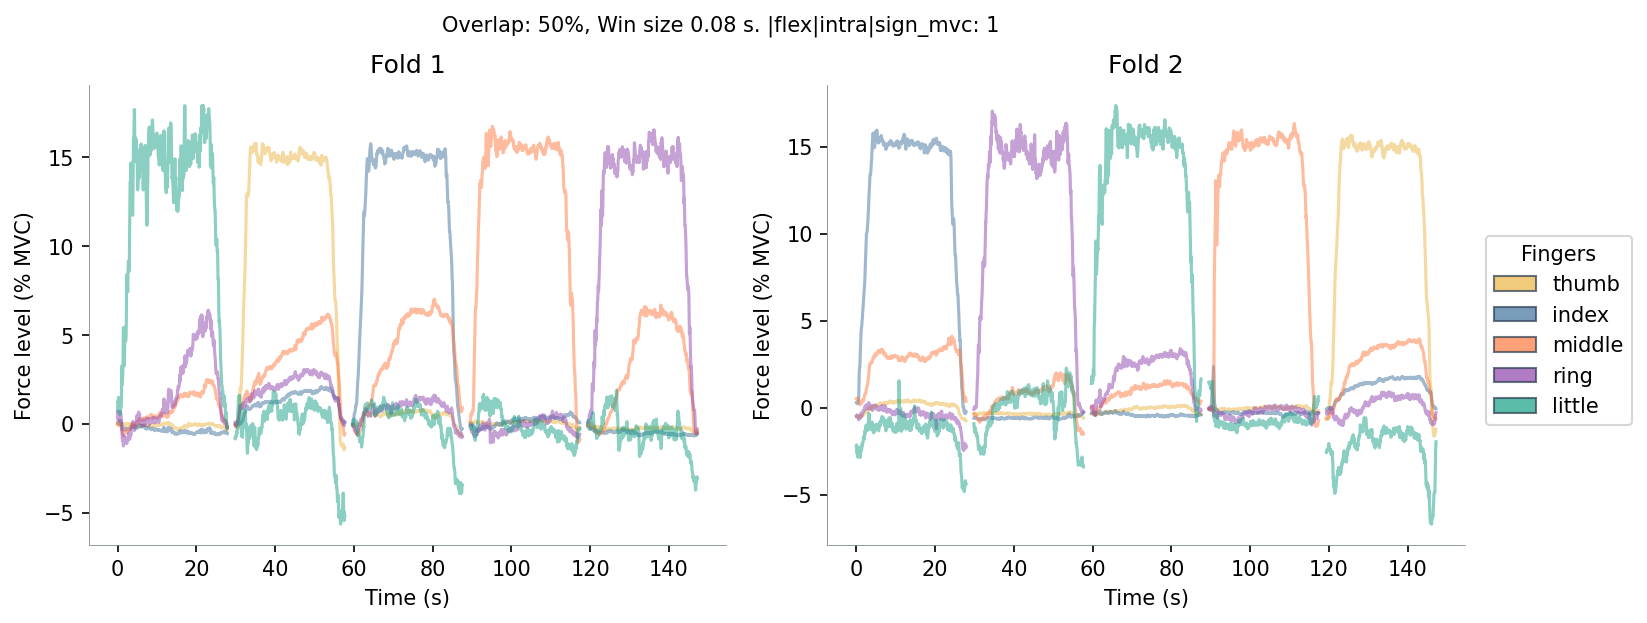

In [43]:
"""
A quick debugging plot: visualize the true force profiles on all fingers for each target finger task and fold.
(2 repetitions in total).
Active finger should have higher force levels than the rest reach a plateau at 15% MVC.
The plot shows the order of the fingers in the regression dataframe.
"""
n_folds = len(y_df_cv)
fig = plt.figure(figsize=(10,4))
gs = gridspec.GridSpec(nrows=1, ncols=n_folds)
buffer_time = 2  # in seconds

for fold_i in range(n_folds):
    ax = fig.add_subplot(gs[fold_i])
    fing_order = np.array(y_df_cv[FING_ORDER_COL].iloc[fold_i])
    print(fing_order)
    ax.set_prop_cycle(color=config.finger_color_list)
    for y in [Y_TRUE_TEST]:
        time_ax_shift = 0
        for fing in fing_order:
            plot_alpha = 0.5 if 'true' not in y else 0.8
            y_df = postprocessed_y_dict[y]
            y_df_fold = y_df[y_df[FOLD_COL]==fold_i]
            temp_df = y_df_fold[y_df_fold[FING_ID_COL]==fing]
            time_ax = temp_df[TIME] + time_ax_shift
            ax.plot(time_ax, temp_df[np.arange(config.n_ind_fingers)],  alpha=0.5)
            time_ax_shift = time_ax.iloc[-1] + buffer_time
    ax.set_title(f'Fold {fold_i+1}')
    ax.set_ylabel(FORCE_MVC_LABEL)
    ax.set_xlabel('Time (s)')
    sns.despine(ax=ax, trim=False)
handles = [Patch(facecolor=c, edgecolor=config.color_dict['midnight_blue'], alpha=LEGEND_ALPHA) for  c in config.finger_color_list]
labels = [fing_name for fing_name in config.finger_label_map.keys()]
fig.legend(handles, labels, loc='center right', title='Fingers', bbox_to_anchor=(1.1, 0.5))
fig.text(0.3, 1, 
         f'Overlap: {overlap_in_perc}%, Win size {win_size_in_sec} s. |{config.direction}|{emg_type}|sign_mvc: {config.sign_mvc}')
fig.tight_layout()

In [44]:
logging.info(f"Saving results to {mu_reg.data_config.results_path}")
mu_reg.save_results(metrics_df_cv, y_df_cv, postprocessed_y_dict, trained_models_df,
                    is_sweep_experiment=sweep_win_size)

INFO:root:Saving results to /Users/farahbaracat/Documents/PhD Research/Code/snn-fingerforce-decoding/results/output_files/S2
INFO:root:Results saved to /Users/farahbaracat/Documents/PhD Research/Code/snn-fingerforce-decoding/results/output_files/S2/baseline_fp32:
 metrics_df_intra_ws0.08_ol50_1_15_cv_on_mu_nfing_1_2_3_4_5_shuffleseed_10_linear_hold_False.pkl 
 y_df_intra_ws0.08_ol50_1_15_cv_on_mu_nfing_1_2_3_4_5_shuffleseed_10_linear_hold_False.pkl 
 y_dict_intra_ws0.08_ol50_1_15_cv_on_mu_nfing_1_2_3_4_5_shuffleseed_10_linear_hold_False.pkl 
 trained_models_intra_ws0.08_ol50_1_15_cv_on_mu_nfing_1_2_3_4_5_shuffleseed_10_linear_hold_False.pkl
